# **CSL2050: Pattern Recognition and Machine Learning**
## **Course Project: Hand-drawn Sketch Recognition**

### **Step 1:** Importing the dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import zipfile
import os

# Define paths
zip_path = "/content/drive/My Drive/Dataset_PNG.zip"  # Space in "My Drive" is fine here
extract_path = "/content/Dataset_PNG"

# Create extract folder if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

# Unzip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Verify extraction
print(os.listdir(extract_path))

Mounted at /content/drive
['sketches_png']


In [2]:
!apt-get install unzip -y
!unzip "/content/drive/My Drive/Dataset_PNG.zip" -d /content/Dataset_PNG

Streaming output truncated to the last 5000 lines.
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15001.png  
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15002.png  
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15003.png  
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15004.png  
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15005.png  
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15006.png  
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15007.png  
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15008.png  
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15009.png  
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15010.png  
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15011.png  
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15012.png  
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15013.png  
  inflating: /content/Dataset_PNG/sketches_png/png/shoe/15014.png

In [3]:
dataset_path = "/content/Dataset_PNG/sketches_png/png"

# Check the extracted dataset folder
print(os.listdir(dataset_path))  # Should show category folders like 'zebra', 'cat', etc.

# Check some images inside a category
sample_category = os.path.join(dataset_path, "zebra")  # Change to any category name
print(os.listdir(sample_category)[:5])  # List first 5 images

['mushroom', 'house', 'cup', 'suitcase', 'mosquito', 'tv', 'revolver', 'calculator', 'wineglass', 'telephone', 'snowman', 'head-phones', 'bookshelf', 'duck', 'sheep', 'megaphone', 'snail', 'feather', 'comb', 'pumpkin', 'spoon', 'cactus', 'tooth', 'bear (animal)', 'tablelamp', 'foot', 'armchair', 'teacup', 'zebra', 'grapes', 'blimp', 'seagull', 'pen', 'mouse (animal)', 'sponge bob', 'space shuttle', 'cake', 'ashtray', 'eye', 'axe', 'wheelbarrow', 'pipe (for smoking)', 'leaf', 'couch', 'table', 'cell phone', 'syringe', 'hammer', 'traffic light', 'fish', 'door handle', 'cigarette', 'suv', 'bread', 'present', 'speed-boat', 'vase', 'owl', 'pig', 'socks', 'door', 'barn', 'cloud', 'helicopter', 'dolphin', 'kangaroo', 'rooster', 'head', 'standing bird', 'castle', 'rifle', 'satellite', 'screwdriver', 'microscope', 'motorbike', 'cow', 'crocodile', 'flashlight', 'bee', 'sailboat', 'sea turtle', 'boomerang', 'camel', 'bell', 'teapot', 'monkey', 'parrot', 'canoe', 'baseball bat', 'skull', 'nose', '

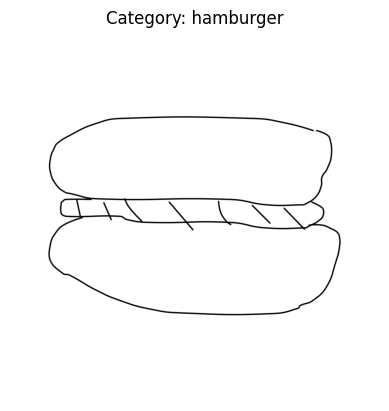

In [4]:
import cv2
import matplotlib.pyplot as plt
import random

# Pick a random category
categories = os.listdir(dataset_path)
random_category = random.choice(categories)

# Pick a random image from the category
image_folder = os.path.join(dataset_path, random_category)
image_name = random.choice(os.listdir(image_folder))
image_path = os.path.join(image_folder, image_name)

# Load and display the image
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  # Convert to grayscale
plt.imshow(image, cmap='gray')
plt.title(f"Category: {random_category}")
plt.axis("off")
plt.show()

In [5]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
categories = os.listdir(dataset_path)
data = []
labels = []
for category in categories:
    category_path = os.path.join(dataset_path, category)
    for img_name in os.listdir(category_path):
        img_path = os.path.join(category_path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Load in grayscale
        img = cv2.resize(img, (64, 64))  # Resize to 64x64
        data.append(img.flatten())  # Flatten the image to a 1D array
        labels.append(category)

# Convert to NumPy arrays
data = np.array(data)
labels = np.array(labels)

# Encode labels
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(labels)

# Split data
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from skimage.feature import hog

# Reshape 'data' correctly to match the original image dimensions
# Assuming your original images were 64x64, you should reshape like this:
data_reshaped = data.reshape(-1, 64, 64)

# Compute HOG features
data_hog = []
for img in data_reshaped:  # Iterate over the reshaped data
    hog_features = hog(img, pixels_per_cell=(8, 8), cells_per_block=(2, 2))
    data_hog.append(hog_features)
data_hog = np.array(data_hog)
print(f"HOG feature size: {data_hog.shape}")

# Split and scale (now with consistent shapes)
X_train_hog, X_test_hog, y_train, y_test = train_test_split(data_hog, labels, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_hog_scaled = scaler.fit_transform(X_train_hog)
X_test_hog_scaled = scaler.transform(X_test_hog)

# Train KNN with distance weighting
knn = KNeighborsClassifier(n_neighbors=10, weights='distance')
knn.fit(X_train_hog_scaled, y_train)
y_pred = knn.predict(X_test_hog_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"KNN Accuracy with HOG and distance weighting (k=10): {accuracy:.2f}")
print(f"Predicted labels (sample): {y_pred[:10]}")
print(f"True labels (sample): {y_test[:10]}")

HOG feature size: (20000, 1764)
KNN Accuracy with HOG and distance weighting (k=10): 0.06
Predicted labels (sample): [ 89  73 107 188 144 196 204 188 216  44]
True labels (sample): [193 218 109 160 203 132  71 188 247  32]


knn vs k graph


In [ ]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import hog
import matplotlib.pyplot as plt
from tqdm import tqdm

# Set paths and parameters
dataset_path = "/content/Dataset_PNG/sketches_png/png"
target_size = (128, 128)  # Increased size for better feature extraction
pixels_per_cell = (16, 16)  # HOG parameters
cells_per_block = (2, 2)
orientations = 9

# Load and preprocess data
def load_and_preprocess_data(dataset_path, max_samples_per_class=500):
    categories = os.listdir(dataset_path)
    data = []
    labels = []

    print("Loading and preprocessing images...")
    for category in tqdm(categories):
        category_path = os.path.join(dataset_path, category)
        image_files = os.listdir(category_path)[:max_samples_per_class]  # Limit samples per class

        for img_name in image_files:
            img_path = os.path.join(category_path, img_name)
            try:
                # Load and preprocess image
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img is None:
                    continue

                # Resize and normalize
                img = cv2.resize(img, target_size)
                img = img / 255.0  # Normalize to [0, 1]

                # Extract HOG features
                hog_features = hog(img, orientations=orientations,
                                 pixels_per_cell=pixels_per_cell,
                                 cells_per_block=cells_per_block,
                                 block_norm='L2-Hys')

                data.append(hog_features)
                labels.append(category)
            except Exception as e:
                print(f"Error processing {img_path}: {str(e)}")

    return np.array(data), np.array(labels)

# Load data
X, y = load_and_preprocess_data(dataset_path)
print(f"Loaded {len(X)} samples with {len(np.unique(y))} classes")

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train KNN model with cross-validation to find best k
def find_best_k(X_train, y_train, X_val, y_val, max_k=30):
    best_k = 1
    best_score = 0
    scores = []

    print("Finding optimal k value...")
    for k in tqdm(range(1, max_k + 1, 2)):
        knn = KNeighborsClassifier(n_neighbors=k, weights='distance', n_jobs=-1)
        knn.fit(X_train, y_train)
        score = knn.score(X_val, y_val)
        scores.append(score)
        if score > best_score:
            best_score = score
            best_k = k

    plt.figure(figsize=(10, 6))
    plt.plot(range(1, max_k + 1, 2), scores, marker='o')
    plt.title('KNN Accuracy vs. k Value')
    plt.xlabel('k')
    plt.ylabel('Validation Accuracy')
    plt.show()

    return best_k

# Create validation set for k tuning
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train_scaled, y_train, test_size=0.2, random_state=42)

best_k = find_best_k(X_train_sub, y_train_sub, X_val, y_val)
print(f"Optimal k value: {best_k}")

# Train final model with best k
final_knn = KNeighborsClassifier(
    n_neighbors=best_k,
    weights='distance',  # Use distance weighting
    metric='euclidean',
    n_jobs=-1  # Use all CPU cores
)

print("Training final model...")
final_knn.fit(X_train_scaled, y_train)

# Evaluate
y_pred = final_knn.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nFinal Test Accuracy: {accuracy:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Visualize some predictions
def visualize_predictions(X_test, y_test, y_pred, label_encoder, n_samples=5):
    plt.figure(figsize=(15, 5))
    indices = np.random.choice(range(len(X_test)), n_samples, replace=False)

    for i, idx in enumerate(indices):
        plt.subplot(1, n_samples, i+1)
        # Since we used HOG features, we can't reconstruct the original image
        # So we'll just show the prediction vs true label
        plt.text(0.5, 0.5,
                f"True: {label_encoder.inverse_transform([y_test[idx]])[0]}\nPred: {label_encoder.inverse_transform([y_pred[idx]])[0]}",
                ha='center', va='center')
        plt.axis('off')
    plt.suptitle("Sample Predictions", y=1.05)
    plt.show()

visualize_predictions(X_test, y_test, y_pred, label_encoder)


  0%|          | 0/250 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
  0%|          | 0/250 [00:00<?, ?it/s]


error: OpenCV(4.11.0) /io/opencv/modules/imgproc/src/canny.cpp:829: error: (-215:Assertion failed) _src.depth() == CV_8U in function 'Canny'


knn using hog features


In [ ]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import MinMaxScaler
from skimage.feature import hog, local_binary_pattern
from tqdm import tqdm
import cv2

# Enhanced feature extraction
# Enhanced feature extraction
def extract_features(img):
    # HOG features
    hog_feat = hog(img, orientations=9, pixels_per_cell=(16,16),
                  cells_per_block=(2,2), block_norm='L2-Hys')

    # LBP features (complements HOG well for sketches)
    lbp = local_binary_pattern(img, P=8, R=1, method='uniform')
    lbp_hist = np.histogram(lbp, bins=10, range=(0,10))[0]

    # Simple shape features
    # Convert image to uint8 before applying Canny
    img_uint8 = (img * 255).astype(np.uint8)
    edges = cv2.Canny(img_uint8, 100, 200)
    edge_density = np.mean(edges)/255

    return np.concatenate([hog_feat, lbp_hist, [edge_density]])

# Load data with enhanced features
def load_enhanced_features(dataset_path, max_samples=100):
    categories = os.listdir(dataset_path)
    X, y = [], []

    for category in tqdm(categories):
        cat_path = os.path.join(dataset_path, category)
        samples = 0

        for img_name in os.listdir(cat_path)[:max_samples]:
            img_path = os.path.join(cat_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue

            img = cv2.resize(img, (128,128))
            img = img / 255.0  # Normalize

            # Extract enhanced features
            features = extract_features(img)
            X.append(features)
            y.append(category)
            samples += 1

            if samples >= max_samples:
                break

    return np.array(X), np.array(y)

# Load data with enhanced features
X, y = load_enhanced_features(dataset_path, max_samples=100)

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Scale features (MinMax works better than StandardScaler for this)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# check
X_train_scaled.shape
# Optimized KNN model
best_knn = KNeighborsClassifier(
    n_neighbors=15,  # Slightly larger k for stability
    weights='distance',
    metric='manhattan',  # Better for high-dim data
    algorithm='ball_tree',  # Better for high dimensions
    n_jobs=-1
)

best_knn.fit(X_train_scaled, y_train)

# Evaluation
y_pred = best_knn.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Improved Accuracy: {accuracy:.4f}")

# Classification report for imbalanced classes
print("\nBalanced Accuracy Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, zero_division=0))

  0%|          | 0/250 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
100%|██████████| 250/250 [03:56<00:00,  1.06it/s]


Improved Accuracy: 0.2650

Balanced Accuracy Report:
                    precision    recall  f1-score   support

          airplane       0.13      0.12      0.13        16
       alarm clock       0.75      0.38      0.50        16
             angel       0.00      0.00      0.00        16
               ant       0.29      0.12      0.17        16
             apple       0.39      0.44      0.41        16
               arm       0.31      0.25      0.28        16
          armchair       0.20      0.12      0.15        16
           ashtray       0.00      0.00      0.00        16
               axe       0.38      0.50      0.43        16
          backpack       0.33      0.19      0.24        16
            banana       0.30      0.38      0.33        16
              barn       0.40      0.12      0.19        16
      baseball bat       0.26      0.38      0.31        16
            basket       0.13      0.19      0.15        16
           bathtub       0.31      0.25      0

pca vs hog

Starting optimized random search with reduced PCA components...
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best params: {'knn__leaf_size': 40, 'knn__n_neighbors': 12, 'pca__n_components': 70}
Test Accuracy with PCA: 0.2988
Original Accuracy (no PCA): 0.2747


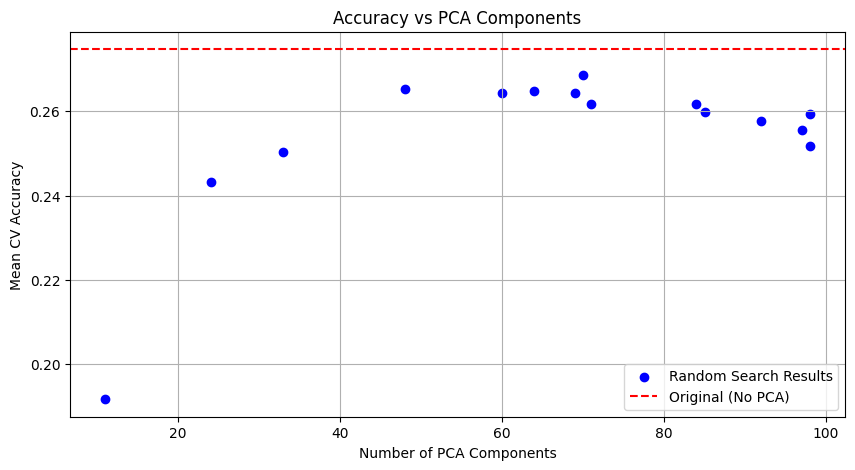

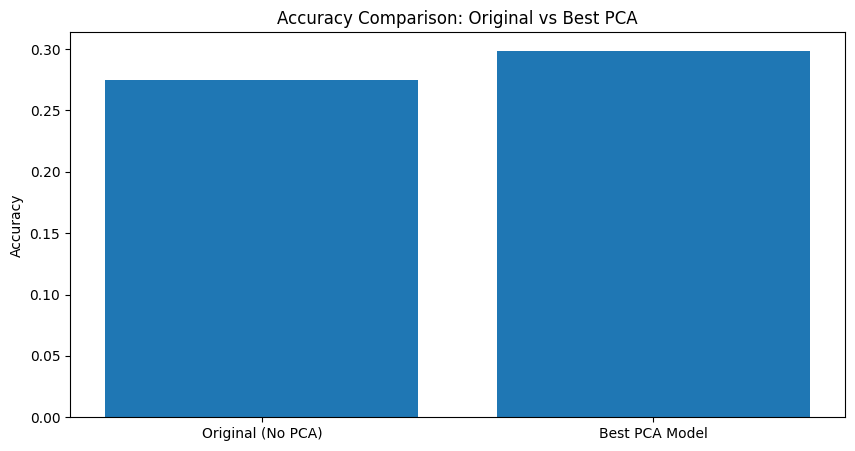

In [ ]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
from scipy.stats import randint
import matplotlib.pyplot as plt
from tempfile import mkdtemp
from shutil import rmtree

# Assuming X_train, X_test, y_train, y_test, X_test_scaled, best_knn are defined
# If not, replace with your data from earlier code

# Define parameter distribution with reduced PCA components
param_dist = {
    'pca__n_components': randint(10, 100),  # Reduced range: 10 to 100 components
    'knn__n_neighbors': randint(5, 25),
    'knn__leaf_size': [20, 30, 40]
}

# Create temporary directory for caching
cachedir = mkdtemp()

# Pipeline with caching
pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('pca', PCA()),
    ('knn', KNeighborsClassifier(weights='distance', metric='manhattan'))
], memory=cachedir)

# Randomized search with fewer iterations
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=15,
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Starting optimized random search with reduced PCA components...")
random_search.fit(X_train, y_train)

# Clean up cache
rmtree(cachedir)

# Evaluate best model
best_model = random_search.best_estimator_
print(f"\nBest params: {random_search.best_params_}")
y_pred = best_model.predict(X_test)
best_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy with PCA: {best_accuracy:.4f}")

# Compare with original KNN (no PCA)
original_accuracy = accuracy_score(y_test, best_knn.predict(X_test_scaled))
print(f"Original Accuracy (no PCA): {original_accuracy:.4f}")

# Visualize accuracy vs PCA components
results = random_search.cv_results_
n_components = results['param_pca__n_components']
accuracies = results['mean_test_score']

plt.figure(figsize=(10, 5))
plt.scatter(n_components, accuracies, c='blue', label='Random Search Results')
plt.axhline(y=original_accuracy, color='r', linestyle='--', label='Original (No PCA)')
plt.xlabel('Number of PCA Components')
plt.ylabel('Mean CV Accuracy')
plt.title('Accuracy vs PCA Components')
plt.legend()
plt.grid(True)
plt.show()

# Bar comparison
plt.figure(figsize=(10, 5))
plt.bar(['Original (No PCA)', 'Best PCA Model'], [original_accuracy, best_accuracy])
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison: Original vs Best PCA')
plt.show()

used cnn for feature extraction and knn for prediction

In [6]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import MinMaxScaler
from tqdm import tqdm
import cv2
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

# Load pretrained ResNet50 model for feature extraction
base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg', input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze the model

# Batch feature extraction using CNN
def extract_cnn_features_batch(images):
    images_preprocessed = preprocess_input(images)
    features = base_model.predict(images_preprocessed, verbose=0)
    return features

# Load data with CNN features
def load_cnn_features(dataset_path, max_samples=100, batch_size=32):
    categories = os.listdir(dataset_path)
    X, y = [], []

    for category in tqdm(categories, desc="Loading categories"):
        cat_path = os.path.join(dataset_path, category)
        samples = 0
        batch_images = []

        for img_name in os.listdir(cat_path)[:max_samples]:
            img_path = os.path.join(cat_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue

            # Convert grayscale to RGB for ResNet50
            img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
            img_resized = cv2.resize(img_rgb, (224, 224))
            batch_images.append(img_resized)
            samples += 1

            # Process batch when full or at the end
            if len(batch_images) == batch_size or (samples == max_samples and batch_images):
                batch_array = np.array(batch_images)
                features = extract_cnn_features_batch(batch_array)
                X.extend(features)
                y.extend([category] * len(features))
                batch_images = []

            if samples >= max_samples:
                break

        # Process any remaining images
        if batch_images:
            batch_array = np.array(batch_images)
            features = extract_cnn_features_batch(batch_array)
            X.extend(features)
            y.extend([category] * len(features))

    return np.array(X), np.array(y)

# Load data
dataset_path = "/content/Dataset_PNG/sketches_png/png"
X, y = load_cnn_features(dataset_path, max_samples=100, batch_size=32)

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Scale features (MinMaxScaler works well with KNN)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Optimized KNN model
knn = KNeighborsClassifier(
    n_neighbors=15,         # Slightly larger k for stability
    weights='distance',     # Weight by inverse distance
    metric='manhattan',     # Manhattan distance often works well with high-dim data
    algorithm='ball_tree',  # Efficient for high-dimensional data
    n_jobs=-1               # Use all available cores
)

# Train the KNN model
knn.fit(X_train_scaled, y_train)

# Predictions
y_pred = knn.predict(X_test_scaled)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"CNN + KNN Accuracy: {accuracy:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, zero_division=0))


y_pred_proba = knn.predict_proba(X_test_scaled)
y_pred_top5 = np.argsort(y_pred_proba, axis=1)[:, -5:]
top5_accuracy = np.mean([y_test[i] in y_pred_top5[i] for i in range(len(y_test))])
print(f"Top-5 Accuracy: {top5_accuracy:.4f}")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Loading categories: 100%|██████████| 250/250 [04:00<00:00,  1.04it/s]


CNN + KNN Accuracy: 0.4530

Classification Report:
                    precision    recall  f1-score   support

          airplane       0.33      0.38      0.35        16
       alarm clock       0.35      0.44      0.39        16
             angel       0.25      0.12      0.17        16
               ant       0.36      0.50      0.42        16
             apple       0.40      0.88      0.55        16
               arm       0.43      0.19      0.26        16
          armchair       0.28      0.31      0.29        16
           ashtray       0.23      0.19      0.21        16
               axe       0.67      0.62      0.65        16
          backpack       0.56      0.62      0.59        16
            banana       0.41      0.44      0.42        16
              barn       0.29      0.12      0.17        16
      baseball bat       0.26      0.50      0.34        16
            basket       0.45      0.31      0.37        16
           bathtub       0.27      0.19      0.2